<a href="https://colab.research.google.com/github/shashintha-hash/ML/blob/main/LR_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R2 score (validation): 0.6200007120403959
MSE (validation): 769498558.1181983
R2 score (test): -14.177844664490994
MSE (test): 3415015049.5104737


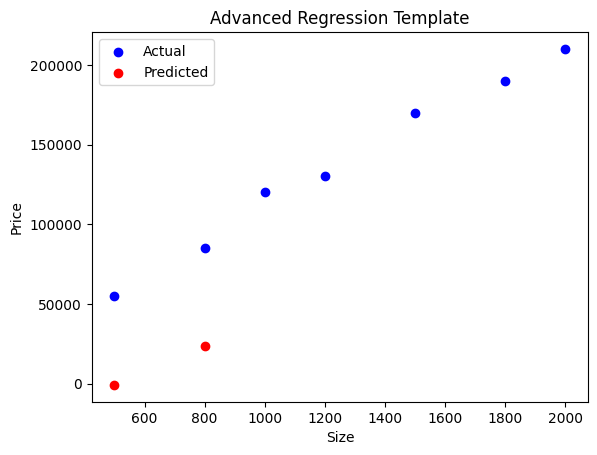

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

data={
    "size": [500, 800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [1, 1, 2, 2, 3, 3, 4],
    "age": [20, 15, 10, 8, 5, 3, 1],
    "bathrooms":[1,1,1,2,2,2,3],
    "price": [55000, 85000, 120000, 130000, 170000, 190000, 210000]
}

df=pd.DataFrame(data)

x=df[["size","bedrooms","age","bathrooms"]]
y=df["price"]

x_temp,x_test,y_temp,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_val,y_train,y_val=train_test_split(x_temp,y_temp,test_size=0.25,random_state=42)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_val_scaled=scaler.transform(x_val)
x_test_scaled=scaler.transform(x_test)

poly=PolynomialFeatures(degree=2,include_bias=False)
x_train_poly=poly.fit_transform(x_train_scaled)
x_val_poly=poly.transform(x_val_scaled)
x_test_poly=poly.transform(x_test_scaled)

model=Ridge(alpha=1.0)
model.fit(x_train_poly,y_train)

y_val_pred=model.predict(x_val_poly)
y_test_pred=model.predict(x_test_poly)


print("R2 score (validation):",r2_score(y_val, y_val_pred))
print("MSE (validation):",mean_squared_error(y_val,y_val_pred) )
print("R2 score (test):",r2_score(y_test, y_test_pred))
print("MSE (test):",mean_squared_error(y_test,y_test_pred) )

plt.scatter(x['size'], y, color='blue', label='Actual')
plt.scatter(x_test['size'], y_test_pred, color='red', label='Predicted')
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Advanced Regression Template")
plt.legend()
plt.show()